--- BEKLEME SÜRESİ KARŞILAŞTIRMA TABLOSU ---
   Deney  Tek Gişe (Bekleme Dk)  Çift Gişe (Bekleme Dk)
 Deney 1                  11.07                    0.39
 Deney 2                  59.78                    0.79
 Deney 3                   7.61                    0.45
 Deney 4                   9.96                    0.39
 Deney 5                  45.58                    0.79
 Deney 6                   6.90                    0.55
 Deney 7                   7.86                    0.54
 Deney 8                  12.86                    0.60
 Deney 9                  16.35                    0.33
Deney 10                   9.69                    0.32
Deney 11                   5.90                    0.79
Deney 12                  11.87                    0.96
Deney 13                  23.61                    1.73
Deney 14                  12.01                    0.69
Deney 15                  12.05                    2.67
Deney 16                  11.50                    1.08
Den

C:\Users\Berk YK\AppData\Local\Temp\ipykernel_17668\999448642.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([[res[0] for res in results_1_teller], [res[0] for res in results_2_tellers]],


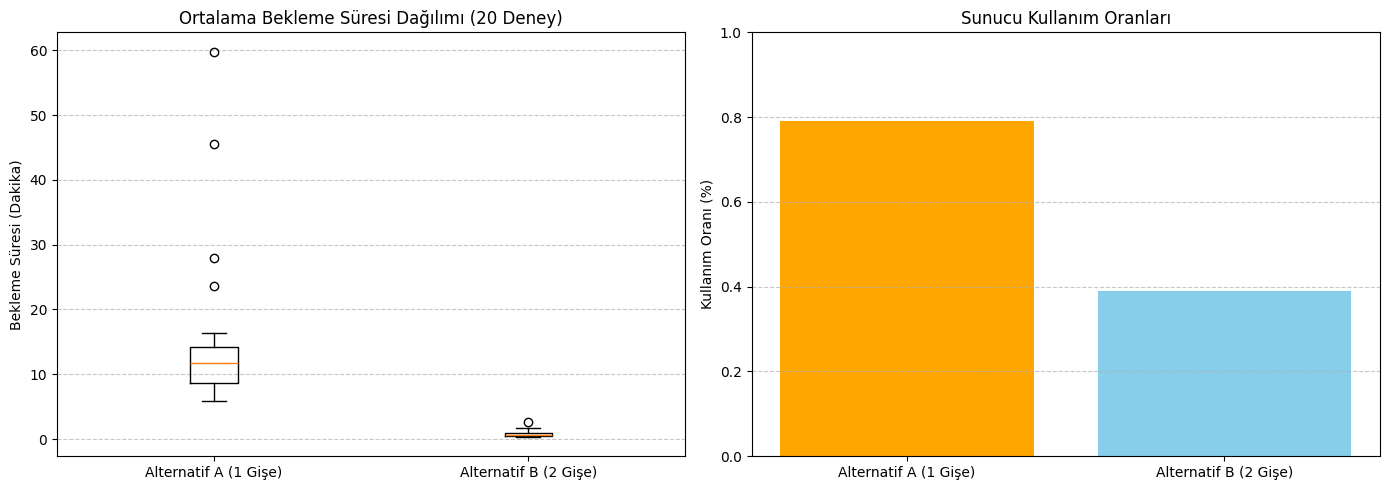

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_bank(num_customers=200, num_tellers=1, mean_interarrival=5, mean_service=4):
    """
    Banka kuyruk sistemini olay tabanlı (event-based) simüle eden fonksiyon.
    """
    # 1. Geliş ve servis sürelerinin üstel dağılıma göre üretilmesi
    interarrivals = np.random.exponential(mean_interarrival, num_customers)
    service_times = np.random.exponential(mean_service, num_customers)
    
    arrival_times = np.cumsum(interarrivals)
    tellers = [0.0] * num_tellers
    
    wait_times = []
    sys_times = []
    events = []

    # 2. Müşteri işlemleri döngüsü
    for i in range(num_customers):
        arrival = arrival_times[i]
        service = service_times[i]
        
        earliest_teller_idx = np.argmin(tellers)
        teller_ready = tellers[earliest_teller_idx]
        
        start_service = max(arrival, teller_ready)
        wait = start_service - arrival
        
        wait_times.append(wait)
        sys_times.append(wait + service)
        
        departure = start_service + service
        tellers[earliest_teller_idx] = departure 
        
        events.append((arrival, 1))
        events.append((departure, -1))

    # 3. Alan bazlı (Area under curve) kesin metrik hesaplamaları
    events.sort(key=lambda x: x[0])
    current_in_system = 0
    last_time = 0
    area_queue = 0
    area_busy = 0

    for time, ev_type in events:
        dt = time - last_time
        
        q_len = max(0, current_in_system - num_tellers)
        area_queue += q_len * dt
        
        busy_tellers = min(current_in_system, num_tellers)
        area_busy += busy_tellers * dt
        
        current_in_system += ev_type
        last_time = time

    total_sim_time = events[-1][0]
    avg_wait = np.mean(wait_times)
    avg_sys_time = np.mean(sys_times)
    avg_q_len = area_queue / total_sim_time
    utilization = (area_busy / num_tellers) / total_sim_time

    return avg_wait, avg_sys_time, avg_q_len, utilization

# 4. Deneylerin Yapılması (20 Bağımsız Tekrar)
num_runs = 20
results_1_teller = []
results_2_tellers = []

np.random.seed(42)

for _ in range(num_runs):
    results_1_teller.append(simulate_bank(num_tellers=1))
    results_2_tellers.append(simulate_bank(num_tellers=2))

# 5. Verilerin Tablolaştırılması
table_data = {
    "Deney": [f"Deney {i+1}" for i in range(num_runs)],
    "Tek Gişe (Bekleme Dk)": [round(res[0], 2) for res in results_1_teller],
    "Çift Gişe (Bekleme Dk)": [round(res[0], 2) for res in results_2_tellers]
}
df_comparison = pd.DataFrame(table_data)
print("--- BEKLEME SÜRESİ KARŞILAŞTIRMA TABLOSU ---")
print(df_comparison.to_string(index=False))
print("-" * 50)

# 6. Genel Ortalama ve Varyasyon Hesaplamaları
mean_wait_1 = np.mean([res[0] for res in results_1_teller])
std_wait_1 = np.std([res[0] for res in results_1_teller])
mean_util_1 = np.mean([res[3] for res in results_1_teller])

mean_wait_2 = np.mean([res[0] for res in results_2_tellers])
std_wait_2 = np.std([res[0] for res in results_2_tellers])
mean_util_2 = np.mean([res[3] for res in results_2_tellers])

print(f"TEK GİŞE: Ort. Bekleme: {mean_wait_1:.2f} dk, Std Sapma: {std_wait_1:.2f}, Kullanım: %{mean_util_1*100:.2f}")
print(f"ÇİFT GİŞE: Ort. Bekleme: {mean_wait_2:.2f} dk, Std Sapma: {std_wait_2:.2f}, Kullanım: %{mean_util_2*100:.2f}")

# 7. Grafikler
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Bekleme Süresi Karşılaştırması (Boxplot ile varyasyonu da gösteriyoruz)
axes[0].boxplot([[res[0] for res in results_1_teller], [res[0] for res in results_2_tellers]], 
                labels=['Alternatif A (1 Gişe)', 'Alternatif B (2 Gişe)'])
axes[0].set_title('Ortalama Bekleme Süresi Dağılımı (20 Deney)')
axes[0].set_ylabel('Bekleme Süresi (Dakika)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Grafik 2: Sunucu Kullanım Oranı Karşılaştırması
axes[1].bar(['Alternatif A (1 Gişe)', 'Alternatif B (2 Gişe)'], [mean_util_1, mean_util_2], color=['orange', 'skyblue'])
axes[1].set_title('Sunucu Kullanım Oranları')
axes[1].set_ylabel('Kullanım Oranı (%)')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()